###1-Importación de datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
## importo los datos del archivo de drive

import pandas as pd

data = pd.read_excel('/content/drive/MyDrive/Eafit/2. Mobile_Banking.xlsx',sheet_name=0)

score = pd.read_excel('/content/drive/MyDrive/Eafit/2. Mobile_Banking.xlsx',sheet_name=1)

,Age,Sex,Edu,Income,CD,App
0,32,1,1,0,1,0
1,40,0,1,1,0,0
2,19,1,1,1,1,1
3,21,0,1,1,1,1
4,45,0,1,2,0,1
...,...,...,...,...,...,...
495,56,1,3,174,0,1
496,41,0,3,174,1,0
497,39,1,3,175,0,0
498,43,1,3,208,0,0


##2- Descripción y Limpieza de datos

In [3]:
## Revisar la composición de los datatypes y valores no nulos

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Age     500 non-null    int64 
 1   Sex     500 non-null    object
 2   Edu     500 non-null    int64 
 3   Income  500 non-null    int64 
 4   CD      500 non-null    object
 5   App     500 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 23.6+ KB


In [4]:
score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Age     20 non-null     int64 
 1   Sex     20 non-null     object
 2   Edu     20 non-null     int64 
 3   Income  20 non-null     int64 
 4   CD      20 non-null     object
dtypes: int64(3), object(2)
memory usage: 932.0+ bytes


Acá podemos ver que tanto la primera como la segunda hoja no cuentan con valores nulos. También se ve la composición de sus datos, los cuales son objetos (2 variable de este tipo en las dos hojas) o enteros. Y vemos el número de entradas (filas) que en uno es 500 y en el otro 20.

In [29]:
data.describe()

,Age,Sex,Edu,Income,CD,App
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,37.534000,0.448000,1.534000,86.58400,0.734000,0.502000
std,13.017055,0.497787,0.640049,53.58606,0.442307,0.500497
min,17.000000,0.000000,1.000000,0.00000,0.000000,0.000000
25%,27.000000,0.000000,1.000000,41.00000,0.000000,0.000000
50%,36.000000,0.000000,1.000000,81.00000,1.000000,1.000000
75%,46.000000,1.000000,2.000000,133.00000,1.000000,1.000000
max,86.000000,1.000000,3.000000,230.00000,1.000000,1.000000


Acá podemos ver parámetros estadísticos sobre los datos contenidos en la primera hoja. Primero podemos ver el conteo de valores, sus medias, desviaciones estándar, valores máximos y mínimos, y percentiles.                
Por ejemplo, podemos observar que el rango de ingresos es muy amplio (0-230), también que este cuenta con una variabilidad ‘SD’ muy alta. En la variable ‘CD’ podemos apreciar que la mayoría, solo el 25% del muestreo, tiene un valor de 0, mientras que el 75 % restante están clasificados como 1, esto se puede apreciar en los percentiles.

In [30]:
score.describe()

,Age,Sex,Edu,Income,CD
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,40.750000,0.550000,1.700000,63.800000,0.800000
std,14.227013,0.510418,0.656947,49.054857,0.410391
min,21.000000,0.000000,1.000000,17.000000,0.000000
25%,27.250000,0.000000,1.000000,35.250000,1.000000
50%,41.000000,1.000000,2.000000,45.000000,1.000000
75%,51.250000,1.000000,2.000000,68.750000,1.000000
max,64.000000,1.000000,3.000000,172.000000,1.000000


Acá podemos ver parámetros estadísticos sobre los datos contenidos en la primera hoja. Primero podemos ver el conteo de valores, sus medias, desviaciones estándar, valores máximos y mínimos, y percentiles.
Acá podemos ver que la variable CD es más homogénea; esto se puede ver en los percentiles. También notamos que los ingresos son más bajos en promedio en la segunda hoja.

In [5]:
data[['Sex','CD']] = data[['Sex','CD']].astype(str).replace({'Male':1,'Female':0,'Yes':1,'No':0})
score[['Sex','CD']] = score[['Sex','CD']].astype(str).replace({'Male':1,'Female':0,'Yes':1,'No':0})

<ipython-input-5-c9c65754533a>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[['Sex','CD']] = data[['Sex','CD']].astype(str).replace({'Male':1,'Female':0,'Yes':1,'No':0})
<ipython-input-5-c9c65754533a>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  score[['Sex','CD']] = score[['Sex','CD']].astype(str).replace({'Male':1,'Female':0,'Yes':1,'No':0})


##3-Divido los datos para el entrenamiento (SPLIT)

In [8]:


XD = data[['Age','Sex','Edu','Income','CD']] #Variables independientes
YD = data[['App']] #Variable dependiente (Variable a predecir)

##4-construyo el modelo de árbol

In [9]:
# Importo las librerías necesarias

import numpy as np, pandas as pd, matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [10]:
# Creo la variable que aloja el modelo

DTmodel = DecisionTreeClassifier(criterion='gini',max_depth=4)

In [11]:
# Entreno el modelo

DTmodel.fit(XD,YD)

DecisionTreeClassifier(max_depth=4)

In [13]:
# Genero las predicciones para el test del modelo

YDpred = DTmodel.predict(XD)



array([1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,

## 5-Construyo las métricas de evaluación del modelo

In [14]:


cm= confusion_matrix(YD,YDpred)
cm

array([[162,  87],
       [107, 144]])

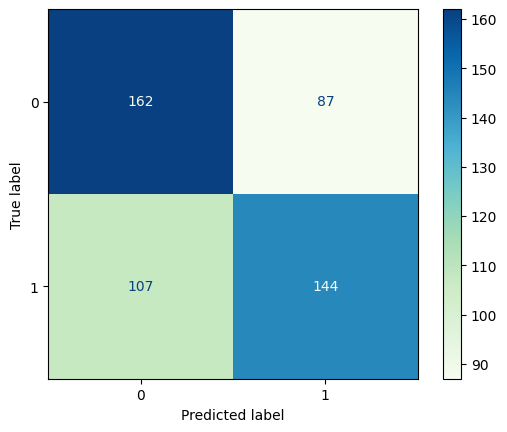

In [15]:
disp= ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels= DTmodel.classes_)
disp.plot(cmap='GnBu')
plt.show()

In [16]:
Vn=cm[0,0]; Fp=cm[0,1]; Fn=cm[1,0]; Vp=cm[1,1]

In [17]:
# Exactitud  (accuracy)
# Número de predicciones correctas sobre el total de predicciones

Exactitud = (Vn+Vp)/cm.sum()
print(f'la exactitud es:{Exactitud: .2%}')



la exactitud es: 61.20%


In [18]:
# Tasa de error
# Número de predicciones incorrectas sobre el total de predicciones

error= 1-Exactitud
print(f'El error del modelo es:{error: .2%}')

El error del modelo es: 38.80%


In [19]:
# Precisión
# Que tan cerca está un resultado del valor verdadero. De los que el modelo calcula como verdaderos, cuáles son realmente verdaderos
precision= Vp/(Fp+Vp)
print(f'La precisión del modelo es:{precision: .2%}')

La precisión del modelo es: 62.34%


In [20]:
# Sensibilidad (Recall)
# La cantidad de positivos bien clasificados por el modelo, respecto al total de positivos

sensibilida= Vp/(Vp+Fn)
print(f'La sensibilidad del modelo es:{sensibilida: .2%}')

La sensibilidad del modelo es: 57.37%


In [21]:
# Especificidad
# La cantidad de negativos bien clasificados por el modelo respecto al total de negativos

especificidad= Vn/(Vn+Fp)
print(f'La especificidad del modelo es:{especificidad: .2%}')

La especificidad del modelo es: 65.06%


Basándonos en las métricas de evaluación, podemos ver primero que la exactitud no es la mejor y que el modelo cuenta con una tasa de error relativamente alta. Por otro lado, los valores que el modelo calculó como positivos, solo el 62% eran realmente positivos, lo que nos indica nuevamente que al modelo le falta precisión. En la sensibilidad, se ve que el modelo clasificó a un poco menos de la mitad de valores positivos de manera errónea. Por último, observamos que el modelo cuenta con una especificidad de 65%, la cual podría ser mejor, ya que hay todavía un porcentaje significativo de falsos positivos.

##6-Hago el pronóstico para nuevos clientes (Generalización)

In [23]:
# Extraigo la información de los clientes que aún no tienen una clasificación


XDgener = score[['Age','Sex','Edu','Income','CD']]

In [25]:
# Hago la predicción para los clientes que no tiene clasificación

YDgener = DTmodel.predict(XDgener)

array([0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0])

##7-Grafico el árbol

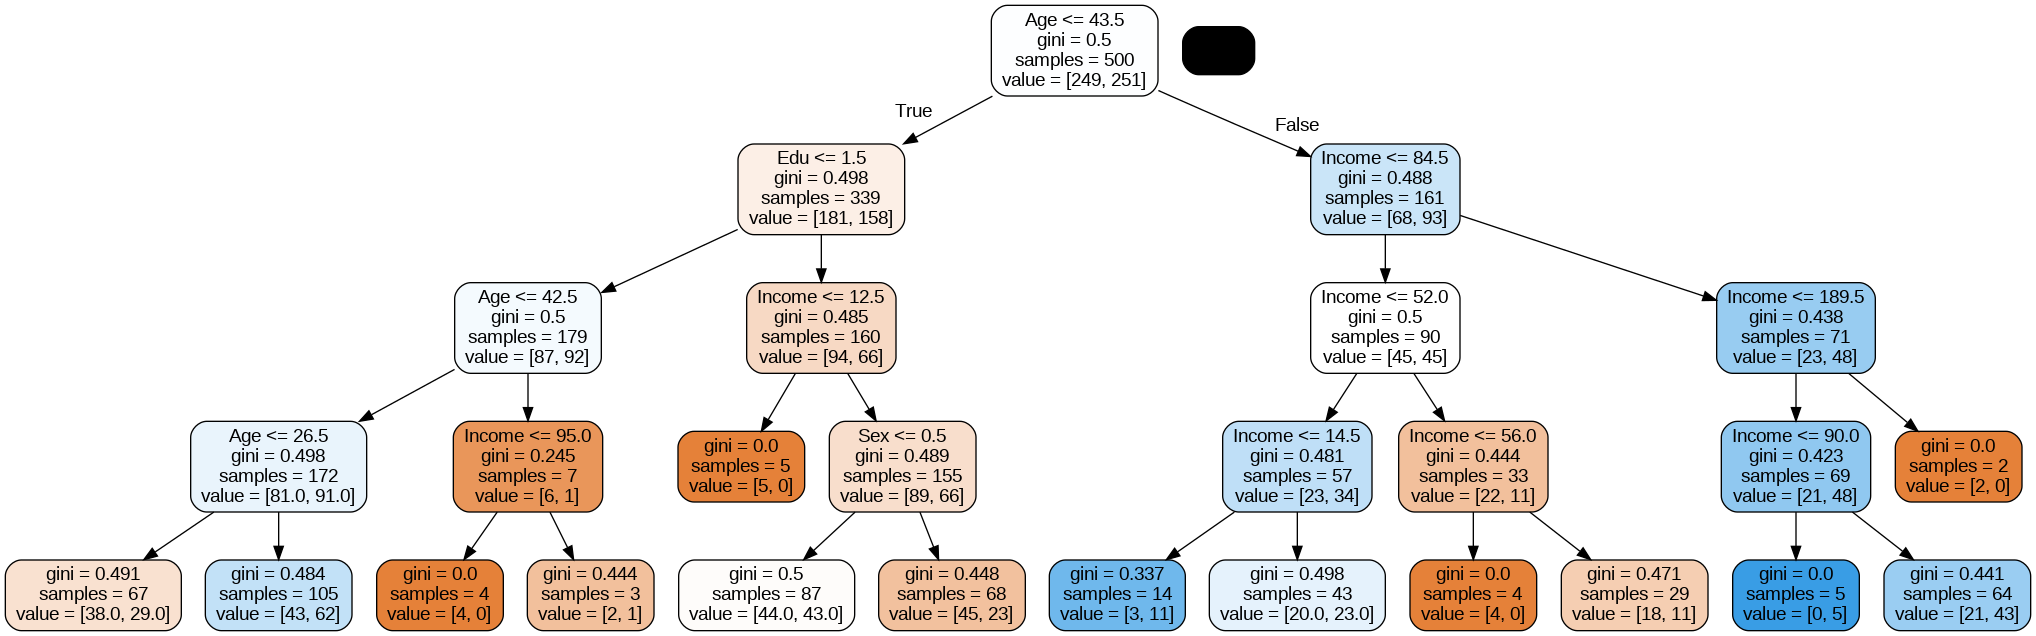

In [27]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image
from six import StringIO
import pydotplus

Var= ['Age','Sex','Edu','Income','CD']
dot_data = StringIO()
export_graphviz(DTmodel, out_file=dot_data, feature_names=Var, filled=True, rounded=True)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [33]:
# Un nodo puro es donde todas las muestras de ese nodo pertenecen a la misma clase

In [32]:
DTmodel.classes_

array([0, 1])

In [34]:
# Value = [no,sí]

## Probabilidad de clientes.

In [51]:
score[2:3] # La probabilidad del cliente número 3 de descargar la aplicación es de 53.4% = 23/43

,Age,Sex,Edu,Income,CD
2,50,0,1,17,0


In [60]:
score[16:17] #El cliente número 17 tiene una posibilidad de descargar la aplicación de 23/68 = 33.8 %


,Age,Sex,Edu,Income,CD
16,38,1,3,153,1


## Reglas de los nodos puros.

Hay 4 Nodos puros en los cuales todos sus clientes no descargan la aplicación. Por otro lado, hay solo un nodo puro en el cual todos los clientes que se clasifican dentro de él descargan el app.

 - La regla para el nodo en el cual hay 5 muestras y ninguna descarga la app es: Age ≤ 43.5, edu > 1.5, Income ≤ 12.5

- La regla para uno de los nodos que cuenta con 4 muestras y ninguna descarga la app es: Age ≤ 43.5, edu ≤ 1.5, Age > 42.5, Income ≤ 95

- La regla para el otro de los nodos que cuenta con 4 muestras y ninguna descarga la app es: Age > 43.5, Income ≤ 84.5, Income > 52, Income ≤ 56

- La regla para el nodo en el cual hay 2 muestras y ninguna descarga la app es:
Age > 43.5, Income > 84.5, Income > 189.5

- Por último, la regla para el nodo puro en el cual todos sus clientes descargan el app es: Age > 43.5, Income > 84.5, Income ≤ 189.5, Income ≤ 90

## Reglas de clientes

In [62]:
score[4:5] # La regla del cliente número 5 es: Age > 43.5, Income ≤ 84.5, Income ≤ 52, Income > 14.5

,Age,Sex,Edu,Income,CD
4,56,1,1,24,1


In [63]:
score[9:10] #La regla para el cliente número 10 es: Age ≤ 43.5, Edu ≤ 1.5, Age ≤ 42.5, Age > 26.5

,Age,Sex,Edu,Income,CD
9,29,0,1,45,1


In [65]:
score[14:15] #La regla para el cliente número 15 es: Age ≤ 43.5, Edu > 1.5, Income > 12.5, Sex > 0.5

,Age,Sex,Edu,Income,CD
14,42,1,2,113,1
